CHUNK 1: Setup and Imports

In [11]:
# Install required packages
!pip install mlxtend seaborn scikit-learn pandas numpy matplotlib -q

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Suppress deprecation warnings specifically
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")

import os
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning'

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Sklearn imports
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC

# MLxtend for association rules
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Distance metrics
from scipy.spatial.distance import pdist, squareform, euclidean
from scipy.stats import zscore

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print("✓ Warnings suppressed")
# Install required packages
!pip install mlxtend seaborn scikit-learn pandas numpy matplotlib -q

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Sklearn imports
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.svm import SVC

# MLxtend for association rules
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Distance metrics
from scipy.spatial.distance import pdist, squareform, euclidean
from scipy.stats import zscore

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

✓ All libraries imported successfully!
✓ Warnings suppressed
✓ All libraries imported successfully!


CHUNK 2: Data Loading


In [12]:
# Load the dataset
# Option 1: From URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'

try:
    df = pd.read_excel(url)
    print("✓ Data loaded from UCI repository")
except:
    print("If UCI link fails, please upload the file manually or use Kaggle dataset")
    # Uncomment below if you upload file to Colab
    # from google.colab import files
    # uploaded = files.upload()
    # df = pd.read_excel('Online Retail.xlsx')

# Display basic information
print(f"\n{'='*60}")
print("DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

✓ Data loaded from UCI repository

DATASET OVERVIEW
Shape: (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First few rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


CHUNK 3: Initial Data Exploration


In [13]:
print(f"{'='*60}")
print("DATA QUALITY ASSESSMENT")
print(f"{'='*60}")

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nMissing CustomerID: {df['CustomerID'].isnull().sum()} ({df['CustomerID'].isnull().sum()/len(df)*100:.2f}%)")

# Data types
print("\nData Types:")
print(df.dtypes)

# Basic statistics
print("\nBasic Statistics:")
df.describe()

DATA QUALITY ASSESSMENT

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing CustomerID: 135080 (24.93%)

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Basic Statistics:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


CHUNK 4: Data Cleaning and Preprocessing


In [14]:
print(f"{'='*60}")
print("DATA CLEANING")
print(f"{'='*60}")

# Store original shape
original_shape = df.shape
print(f"Original shape: {original_shape}")

# 1. Remove rows with missing CustomerID
df_clean = df[df['CustomerID'].notna()].copy()
print(f"After removing missing CustomerID: {df_clean.shape}")

# 2. Remove cancellations (InvoiceNo starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"After removing cancellations: {df_clean.shape}")

# 3. Remove negative quantities and prices
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"After removing negative values: {df_clean.shape}")

# 4. Convert CustomerID to integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 5. Ensure InvoiceDate is datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# 6. Create TotalAmount feature
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"\n✓ Cleaning complete!")
print(f"Rows removed: {original_shape[0] - df_clean.shape[0]} ({(original_shape[0] - df_clean.shape[0])/original_shape[0]*100:.2f}%)")

# Display cleaned data sample
print("\nCleaned Data Sample:")
df_clean.head(10)

DATA CLEANING
Original shape: (541909, 8)
After removing missing CustomerID: (406829, 8)
After removing cancellations: (397924, 8)
After removing negative values: (397884, 8)

✓ Cleaning complete!
Rows removed: 144025 (26.58%)

Cleaned Data Sample:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08


CHUNK 5: Feature Engineering - RFM Analysis


RFM FEATURE ENGINEERING
Reference Date: 2011-12-10 12:50:00

RFM Statistics:
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000


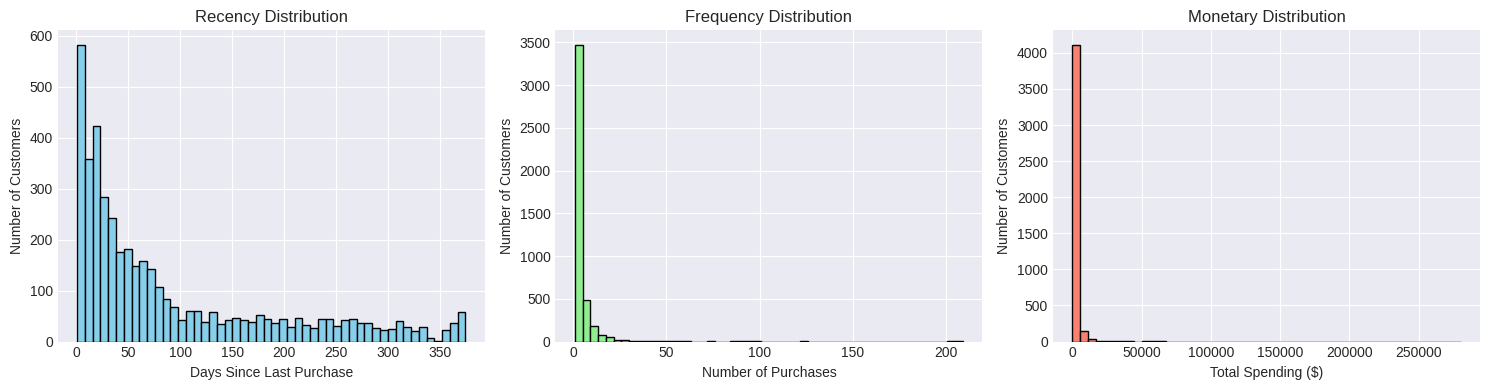


✓ RFM features created for 4338 customers


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [15]:
print(f"{'='*60}")
print("RFM FEATURE ENGINEERING")
print(f"{'='*60}")

# Reference date (1 day after last transaction)
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date}")

# Calculate RFM metrics per customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency
    'TotalAmount': 'sum'  # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Display RFM statistics
print("\nRFM Statistics:")
print(rfm.describe())

# Visualize RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['Recency'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(rfm['Frequency'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Frequency Distribution')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')

axes[2].hist(rfm['Monetary'], bins=50, color='salmon', edgecolor='black')
axes[2].set_title('Monetary Distribution')
axes[2].set_xlabel('Total Spending ($)')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

print(f"\n✓ RFM features created for {len(rfm)} customers")
rfm.head(10)

CHUNK 6: Country Encoding


CATEGORICAL ENCODING

Top 10 Countries by Transaction Volume:
Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64

✓ Encoded 37 countries
Final feature set shape: (4338, 42)


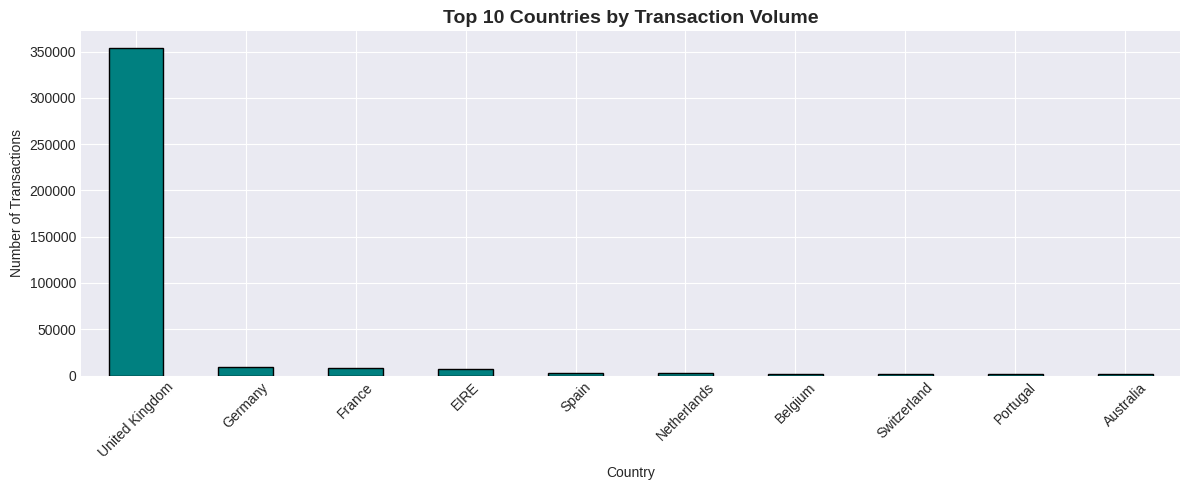

,CustomerID,Recency,Frequency,Monetary,PrimaryCountry,Country_Australia,Country_Austria,Country_Bahrain,Country_Belgium,Country_Brazil,Country_Canada,Country_Channel Islands,Country_Cyprus,Country_Czech Republic,Country_Denmark,Country_EIRE,Country_European Community,Country_Finland,Country_France,Country_Germany,Country_Greece,Country_Iceland,Country_Israel,Country_Italy,Country_Japan,Country_Lebanon,Country_Lithuania,Country_Malta,Country_Netherlands,Country_Norway,Country_Poland,Country_Portugal,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,12346,326,1,77183.60,United Kingdom,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,12347,2,7,4310.00,Iceland,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,12348,75,4,1797.24,Finland,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,12349,19,1,1757.55,Italy,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,12350,310,1,334.40,Norway,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
print(f"{'='*60}")
print("CATEGORICAL ENCODING")
print(f"{'='*60}")

# Get top countries by transaction volume
top_countries = df_clean['Country'].value_counts().head(10)
print("\nTop 10 Countries by Transaction Volume:")
print(top_countries)

# Create country features for each customer
customer_country = df_clean.groupby('CustomerID')['Country'].agg(lambda x: x.mode()[0]).reset_index()
customer_country.columns = ['CustomerID', 'PrimaryCountry']

# One-hot encode countries
country_encoded = pd.get_dummies(customer_country['PrimaryCountry'], prefix='Country')
customer_country = pd.concat([customer_country, country_encoded], axis=1)

# Merge with RFM
rfm_encoded = rfm.merge(customer_country, on='CustomerID', how='left')

print(f"\n✓ Encoded {len(country_encoded.columns)} countries")
print(f"Final feature set shape: {rfm_encoded.shape}")

# Visualize country distribution
plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Top 10 Countries by Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rfm_encoded.head()

CHUNK 7: Similarity Matrix - Euclidean Distance


SIMILARITY ANALYSIS - EUCLIDEAN DISTANCE


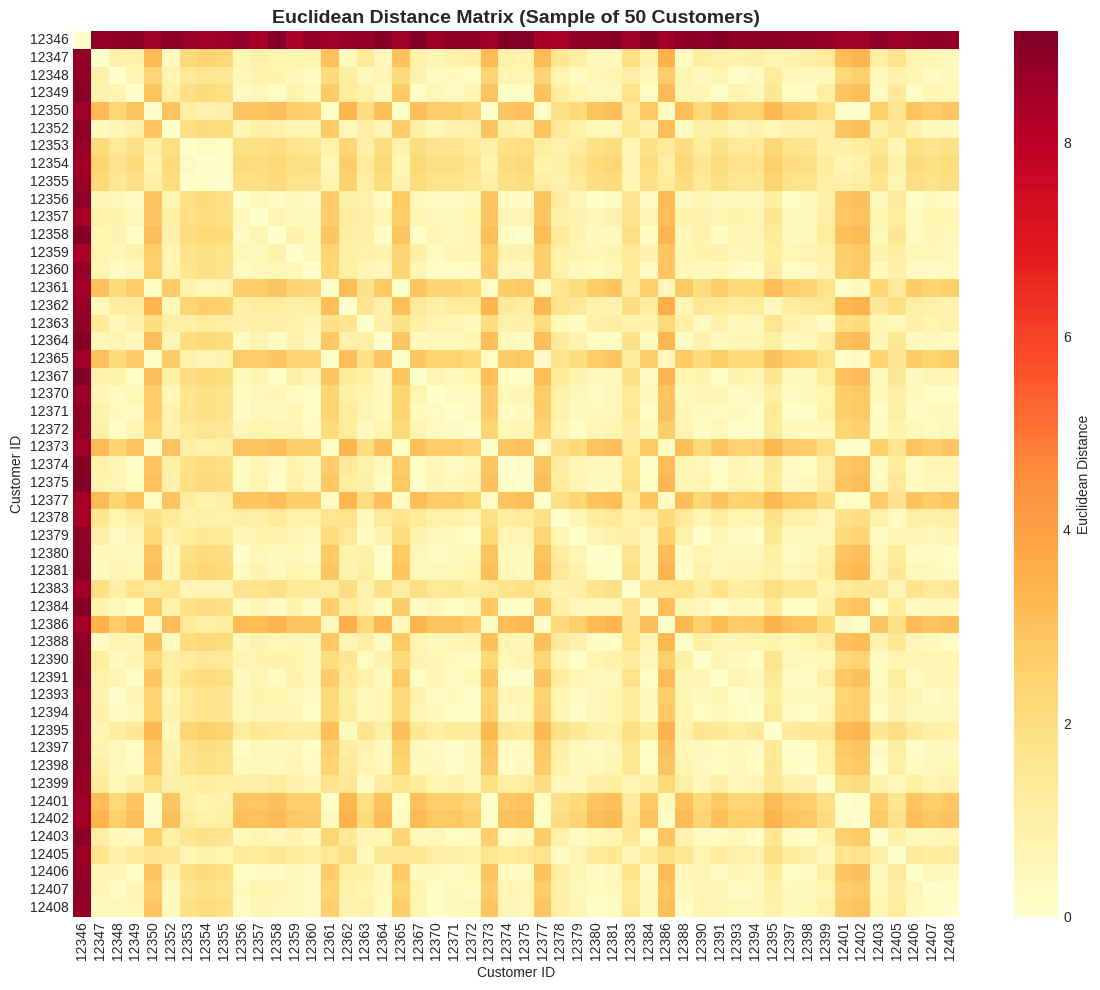

✓ Euclidean distance matrix computed
Matrix shape: (50, 50)

Distance statistics:
Mean: 1.57
Min: 0.00
Max: 9.15


In [17]:
print(f"{'='*60}")
print("SIMILARITY ANALYSIS - EUCLIDEAN DISTANCE")
print(f"{'='*60}")

# Standardize RFM features for distance calculation
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Sample customers for visualization (using first 50 for clarity)
sample_size = 50
rfm_sample = rfm_scaled[:sample_size]
customer_ids_sample = rfm['CustomerID'].iloc[:sample_size].values

# Compute Euclidean distance matrix
euclidean_dist = squareform(pdist(rfm_sample, metric='euclidean'))

# Visualize as heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(euclidean_dist,
            cmap='YlOrRd',
            xticklabels=customer_ids_sample,
            yticklabels=customer_ids_sample,
            cbar_kws={'label': 'Euclidean Distance'})
plt.title('Euclidean Distance Matrix (Sample of 50 Customers)', fontsize=14, fontweight='bold')
plt.xlabel('Customer ID')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

print(f"✓ Euclidean distance matrix computed")
print(f"Matrix shape: {euclidean_dist.shape}")
print(f"\nDistance statistics:")
print(f"Mean: {euclidean_dist.mean():.2f}")
print(f"Min: {euclidean_dist.min():.2f}")
print(f"Max: {euclidean_dist.max():.2f}")

CHUNK 8: Jaccard Similarity


SIMILARITY ANALYSIS - JACCARD SIMILARITY


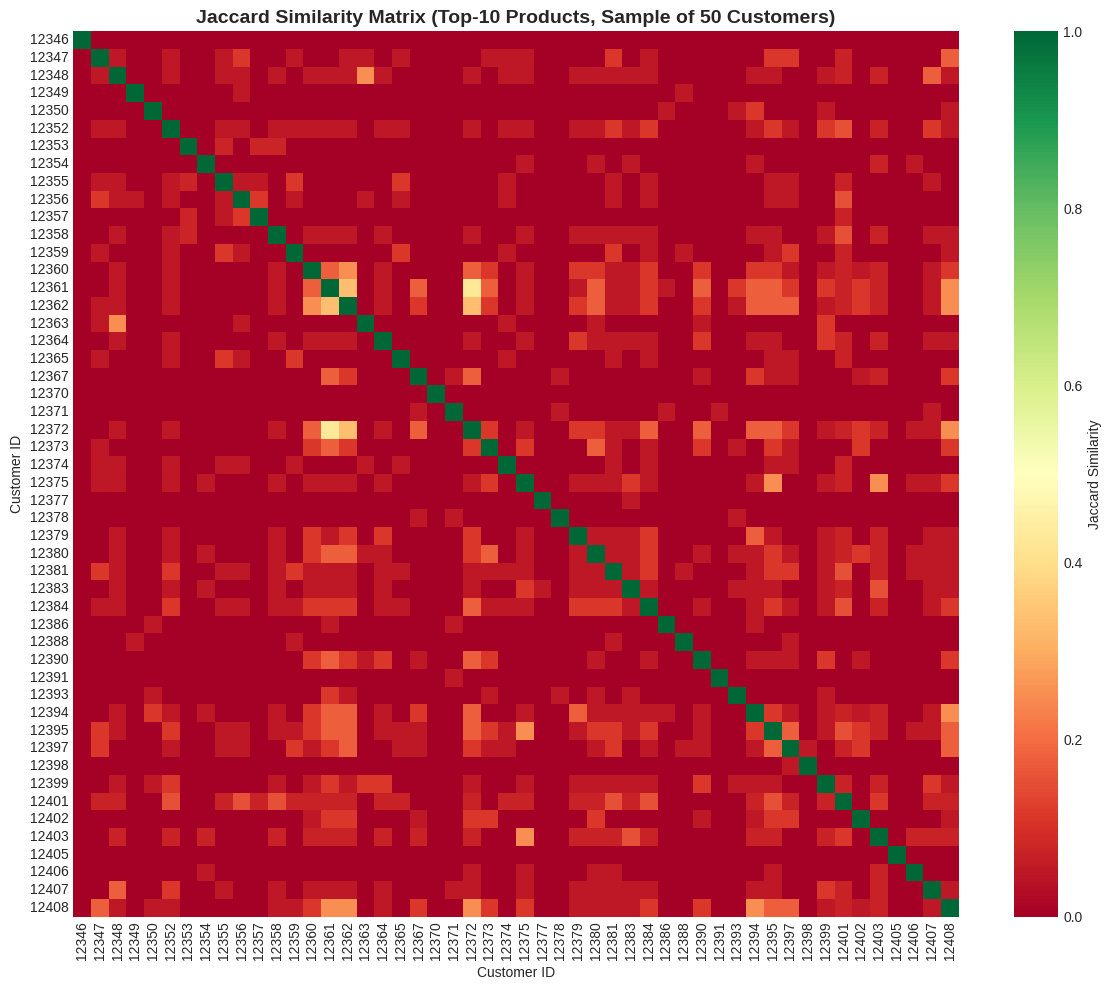

✓ Jaccard similarity matrix computed
Matrix shape: (50, 50)

Similarity statistics:
Mean: 0.045
Min: 0.000
Max (excluding diagonal): 0.429


In [18]:
print(f"{'='*60}")
print("SIMILARITY ANALYSIS - JACCARD SIMILARITY")
print(f"{'='*60}")

# Get top 10 products purchased by each customer
customer_products = df_clean.groupby('CustomerID')['StockCode'].apply(
    lambda x: set(x.value_counts().head(10).index)
).reset_index()
customer_products.columns = ['CustomerID', 'TopProducts']

# Function to compute Jaccard similarity
def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

# Sample customers
sample_customers = customer_products.iloc[:sample_size]

# Compute Jaccard similarity matrix
jaccard_matrix = np.zeros((len(sample_customers), len(sample_customers)))

for i in range(len(sample_customers)):
    for j in range(len(sample_customers)):
        jaccard_matrix[i, j] = jaccard_similarity(
            sample_customers.iloc[i]['TopProducts'],
            sample_customers.iloc[j]['TopProducts']
        )

# Visualize
plt.figure(figsize=(12, 10))
sns.heatmap(jaccard_matrix,
            cmap='RdYlGn',
            xticklabels=sample_customers['CustomerID'].values,
            yticklabels=sample_customers['CustomerID'].values,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Jaccard Similarity'})
plt.title('Jaccard Similarity Matrix (Top-10 Products, Sample of 50 Customers)',
          fontsize=14, fontweight='bold')
plt.xlabel('Customer ID')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

print(f"✓ Jaccard similarity matrix computed")
print(f"Matrix shape: {jaccard_matrix.shape}")
print(f"\nSimilarity statistics:")
print(f"Mean: {jaccard_matrix.mean():.3f}")
print(f"Min: {jaccard_matrix.min():.3f}")
print(f"Max (excluding diagonal): {np.max(jaccard_matrix[~np.eye(jaccard_matrix.shape[0], dtype=bool)]):.3f}")

CHUNK 9: K-Means Clustering - Elbow Method


K-MEANS CLUSTERING - OPTIMAL K SELECTION


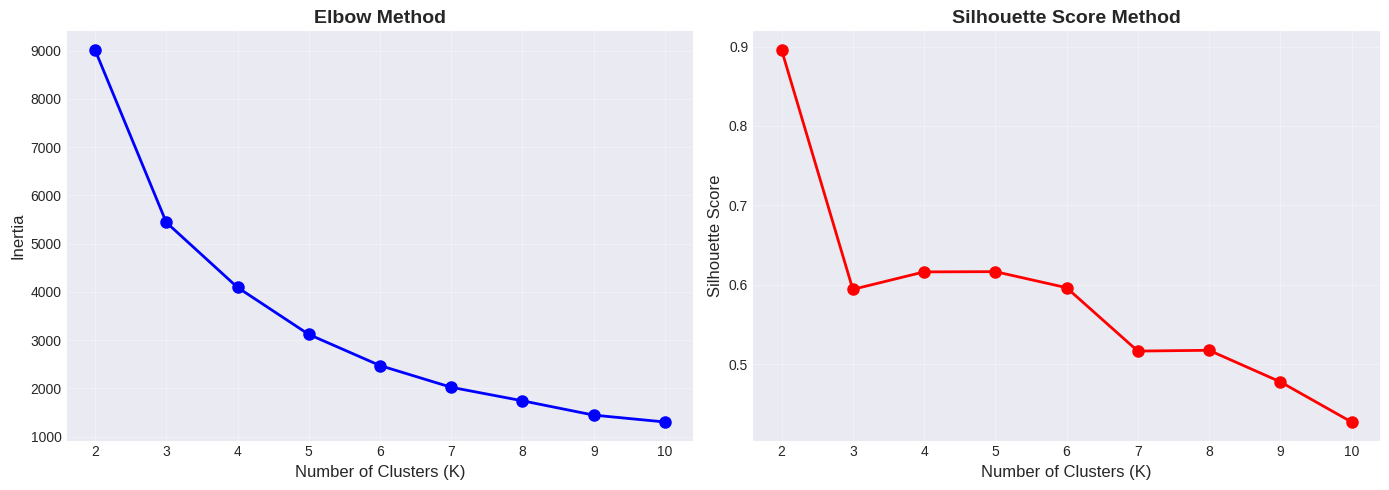


✓ Optimal K based on silhouette score: 2
Best silhouette score: 0.896


In [19]:
print(f"{'='*60}")
print("K-MEANS CLUSTERING - OPTIMAL K SELECTION")
print(f"{'='*60}")

# Prepare data
X = rfm[['Recency', 'Frequency', 'Monetary']].values
X_scaled = StandardScaler().fit_transform(X)

# Elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score Method', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal K
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal K based on silhouette score: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

CHUNK 10: K-Means Clustering - Final Model


K-MEANS CLUSTERING - FINAL MODEL

Cluster Distribution:
KMeans_Cluster
0    1082
1    3230
2      26
Name: count, dtype: int64

Cluster Characteristics:
                   Recency  Frequency      Monetary
KMeans_Cluster                                     
0               247.106285   1.582255    631.424206
1                41.454180   4.672755   1855.942345
2                 6.038462  66.423077  85904.351538


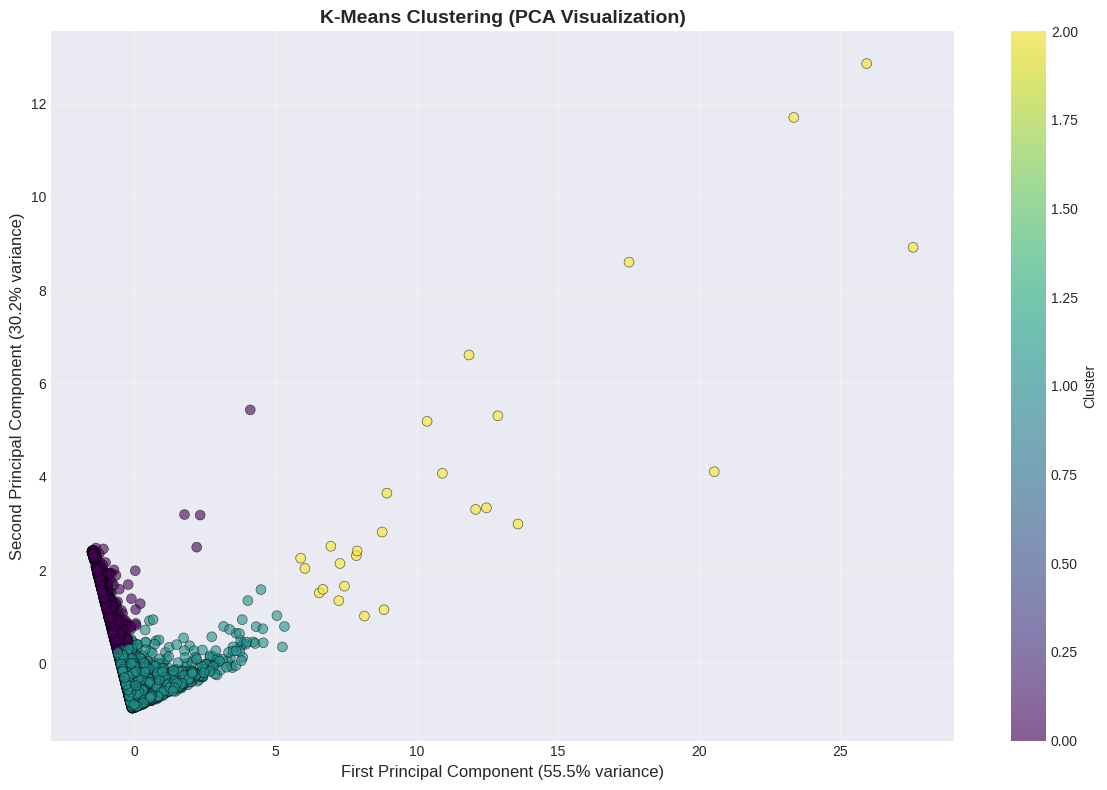


✓ K-Means clustering complete
Total variance explained by 2 PCs: 85.8%


In [20]:
print(f"{'='*60}")
print("K-MEANS CLUSTERING - FINAL MODEL")
print(f"{'='*60}")

# Fit K-Means with optimal K
optimal_k = 3  # You can change this based on previous analysis
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster statistics
print(f"\nCluster Distribution:")
print(rfm['KMeans_Cluster'].value_counts().sort_index())

print(f"\nCluster Characteristics:")
cluster_summary = rfm.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print(cluster_summary)

# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Visualize clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=rfm['KMeans_Cluster'],
                     cmap='viridis',
                     s=50,
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('K-Means Clustering (PCA Visualization)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ K-Means clustering complete")
print(f"Total variance explained by 2 PCs: {pca.explained_variance_ratio_.sum():.1%}")

CHUNK 11: DBSCAN Clustering


DBSCAN CLUSTERING
Tuning DBSCAN parameters...
eps=0.3, min_samples=5: 2 clusters, 107 noise points, silhouette=0.674
eps=0.5, min_samples=10: 2 clusters, 67 noise points, silhouette=0.666

✓ Best parameters: {'eps': 0.3, 'min_samples': 5}
Best silhouette score: 0.674

Final DBSCAN Results:
Number of clusters: 2
Number of noise points: 107 (2.5%)

Cluster Distribution:
DBSCAN_Cluster
-1     107
 0    4225
 1       6
Name: count, dtype: int64


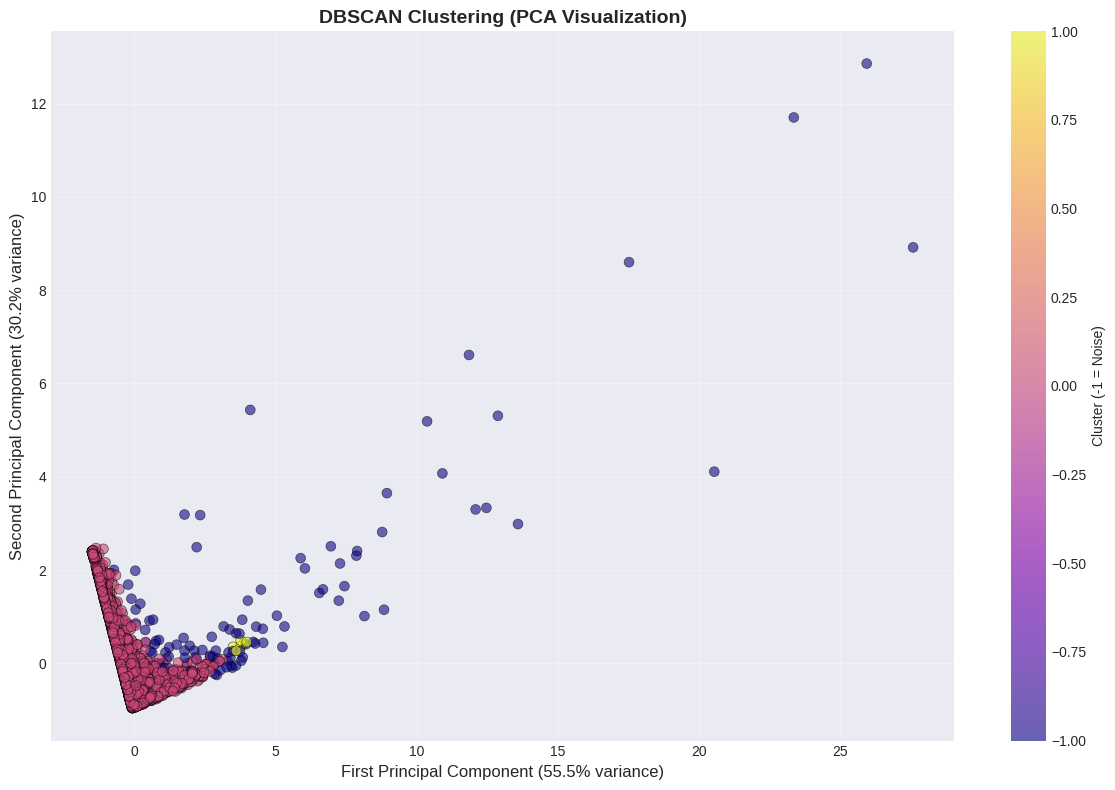

In [21]:
print(f"{'='*60}")
print("DBSCAN CLUSTERING")
print(f"{'='*60}")

# Tune DBSCAN parameters
# Test different eps values
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [5, 10, 15]

best_score = -1
best_params = {}

print("Tuning DBSCAN parameters...")
for eps in eps_values:
    for min_samp in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_scaled)

        # Only calculate silhouette if we have more than 1 cluster
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1 and n_clusters < len(X_scaled) - 1:
            # Calculate silhouette only for non-noise points
            non_noise_mask = labels != -1
            if non_noise_mask.sum() > 1:
                score = silhouette_score(X_scaled[non_noise_mask], labels[non_noise_mask])

                if score > best_score:
                    best_score = score
                    best_params = {'eps': eps, 'min_samples': min_samp}

                print(f"eps={eps}, min_samples={min_samp}: {n_clusters} clusters, {n_noise} noise points, silhouette={score:.3f}")

print(f"\n✓ Best parameters: {best_params}")
print(f"Best silhouette score: {best_score:.3f}")

# Fit DBSCAN with best parameters
dbscan_best = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
rfm['DBSCAN_Cluster'] = dbscan_best.fit_predict(X_scaled)

# Cluster statistics
n_clusters_dbscan = len(set(rfm['DBSCAN_Cluster'])) - (1 if -1 in rfm['DBSCAN_Cluster'].values else 0)
n_noise_dbscan = list(rfm['DBSCAN_Cluster']).count(-1)

print(f"\nFinal DBSCAN Results:")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan} ({n_noise_dbscan/len(rfm)*100:.1f}%)")

print(f"\nCluster Distribution:")
print(rfm['DBSCAN_Cluster'].value_counts().sort_index())

# Visualize DBSCAN clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=rfm['DBSCAN_Cluster'],
                     cmap='plasma',
                     s=50,
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)
plt.colorbar(scatter, label='Cluster (-1 = Noise)')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title('DBSCAN Clustering (PCA Visualization)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CHUNK 12: Clustering Comparison


CLUSTERING COMPARISON


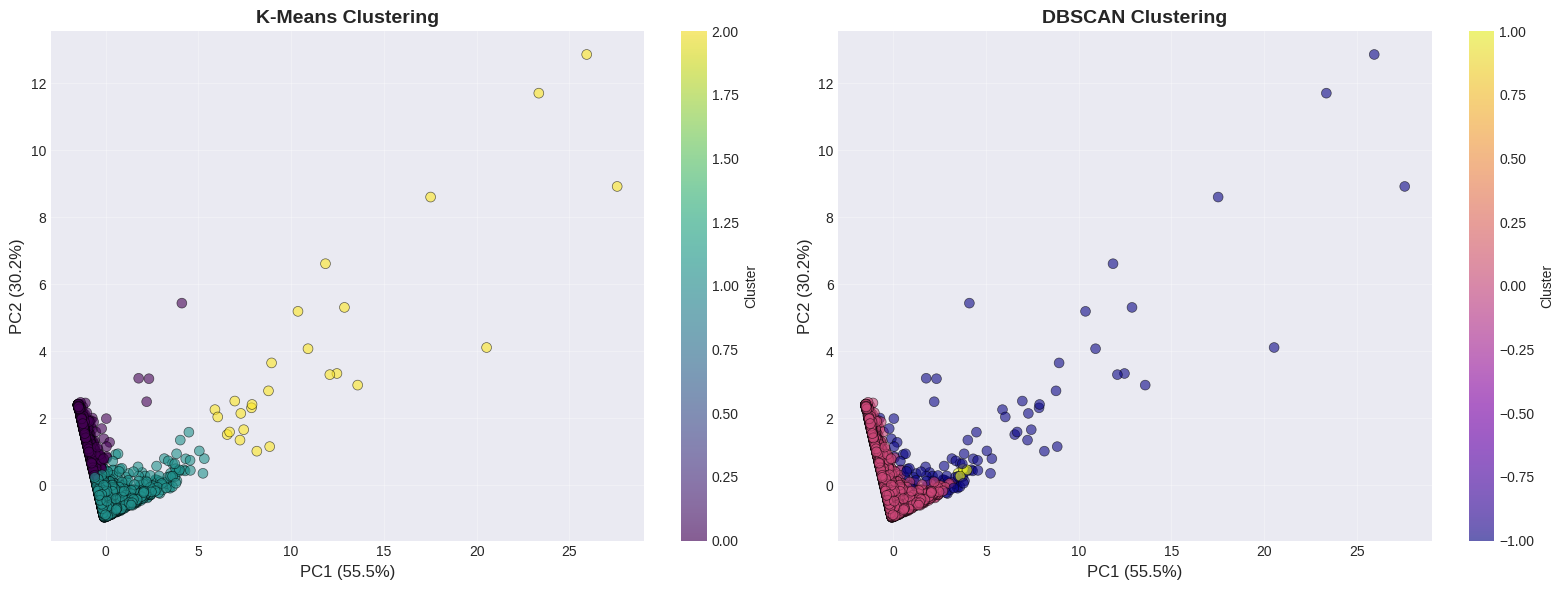


Clustering Comparison Summary:

K-Means:
  - Number of clusters: 3
  - All points assigned to clusters
  - Assumes spherical clusters

DBSCAN:
  - Number of clusters: 2
  - Noise points: 107 (2.5%)
  - Can detect arbitrary shaped clusters
  - Best params: eps=0.3, min_samples=5

✓ Clustering analysis complete


In [22]:
print(f"{'='*60}")
print("CLUSTERING COMPARISON")
print(f"{'='*60}")

# Compare K-Means vs DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=rfm['KMeans_Cluster'],
                          cmap='viridis',
                          s=50,
                          alpha=0.6,
                          edgecolors='black',
                          linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
axes[0].set_title('K-Means Clustering', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
fig.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                          c=rfm['DBSCAN_Cluster'],
                          cmap='plasma',
                          s=50,
                          alpha=0.6,
                          edgecolors='black',
                          linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
axes[1].set_title('DBSCAN Clustering', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
fig.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()

# Comparison summary
print("\nClustering Comparison Summary:")
print(f"\nK-Means:")
print(f"  - Number of clusters: {optimal_k}")
print(f"  - All points assigned to clusters")
print(f"  - Assumes spherical clusters")

print(f"\nDBSCAN:")
print(f"  - Number of clusters: {n_clusters_dbscan}")
print(f"  - Noise points: {n_noise_dbscan} ({n_noise_dbscan/len(rfm)*100:.1f}%)")
print(f"  - Can detect arbitrary shaped clusters")
print(f"  - Best params: eps={best_params['eps']}, min_samples={best_params['min_samples']}")

print("\n✓ Clustering analysis complete")

CHUNK 13: Prepare Data for Association Rules


In [23]:
print(f"{'='*60}")
print("ASSOCIATION RULE MINING - DATA PREPARATION")
print(f"{'='*60}")

# Create a basket of items for each transaction
basket = df_clean.groupby(['InvoiceNo', 'StockCode'])['Quantity'].sum().unstack().fillna(0)

# Convert to binary (1 if item purchased, 0 otherwise)
basket_binary = basket.applymap(lambda x: 1 if x > 0 else 0)

print(f"Basket shape: {basket_binary.shape}")
print(f"Number of transactions: {basket_binary.shape[0]}")
print(f"Number of unique products: {basket_binary.shape[1]}")

# Remove products that appear in too few transactions
min_support_count = int(0.01 * len(basket_binary))  # At least 1% of transactions
frequent_items = basket_binary.sum(axis=0) >= min_support_count
basket_filtered = basket_binary.loc[:, frequent_items]

print(f"\nAfter filtering (min 1% support):")
print(f"Number of products retained: {basket_filtered.shape[1]}")

# Display sample
print("\nSample of basket data:")
basket_filtered.head(10)

ASSOCIATION RULE MINING - DATA PREPARATION
Basket shape: (18532, 3665)
Number of transactions: 18532
Number of unique products: 3665

After filtering (min 1% support):
Number of products retained: 629

Sample of basket data:


StockCode,15036,17003,20675,20676,20677,20679,20685,20711,20712,20713,20717,20718,20719,20723,20724,20725,20726,20727,20728,20749,20750,20754,20914,20969,20970,20971,20972,20973,20974,20975,20979,20981,20982,20983,20992,21034,21035,21078,21080,21086,21094,21108,21121,21122,21124,21136,21137,21154,21155,21156,21164,21165,21166,21169,21172,21174,21175,21181,21210,21212,21213,21216,21217,21218,21231,21232,21238,21239,21240,21242,21259,21314,21326,21328,21340,21380,21385,21411,21429,21430,21479,21481,21484,21485,21497,21498,21499,21500,21506,21507,21509,21519,21523,21524,21531,21533,21535,21539,21558,21559,21592,21621,21623,21668,21669,21670,21671,21672,21673,21703,21704,21731,21733,21745,21746,21754,21755,21756,21770,21790,21791,21843,21868,21871,21874,21876,21877,21888,21889,21891,21892,21899,21900,21901,21907,21908,21912,21914,21915,21916,21917,21918,21928,21929,21930,21931,21932,21933,21935,21936,21937,21974,21975,21976,21977,21980,21981,21982,21985,21989,21992,21993,22027,22028,22029,22030,22037,22041,22045,22077,22079,22082,22083,22084,22086,22087,22090,22111,22112,22113,22114,22138,22139,22141,22142,22144,22147,22149,22150,22151,22158,22169,22170,22171,22173,22178,22189,22191,22192,22193,22195,22196,22197,22208,22212,22219,22271,22273,22274,22294,22295,22296,22297,22302,22303,22326,22328,22333,22348,22352,22355,22356,22367,22371,22379,22380,22381,22382,22383,22384,22385,22386,22398,22411,22413,22417,22418,22423,22424,22427,22429,22431,22432,22433,22435,22456,22457,22464,22467,22469,22470,22487,22488,22489,22491,22492,22499,22501,22502,22505,22507,22508,22534,22549,22551,22553,22554,22555,22556,22557,22558,22560,22561,22562,22563,22568,22569,22570,22577,22578,22579,22585,22595,22596,22605,22607,22616,22617,22619,22620,22621,22622,22623,22624,22625,22627,22629,22630,22631,22632,22633,22634,22637,22644,22645,22646,22652,22654,22659,22661,22662,22663,22665,22666,22667,22668,22670,22690,22692,22693,22694,22697,22698,22699,22712,22716,22720,22721,22722,22723,22725,22726,22727,22728,22729,22730,22734,22737,22739,22745,22746,22748,22749,22750,22751,22752,22754,22755,22759,22766,22767,22768,22771,22776,22784,22791,22795,22796,22798,22804,22834,22835,22840,22841,22844,22845,22846,22847,22851,22865,22866,22867,22892,22895,22896,22898,22899,22900,22904,22906,22907,22908,22909,22910,22916,22917,22918,22919,22920,22940,22941,22951,22952,22957,22960,22961,22962,22963,22964,22965,22966,22969,22970,22971,22978,22979,22980,22983,22988,22989,22991,22992,22993,22996,22998,22999,23000,23012,23052,23076,23077,23078,23080,23082,23083,23084,23091,23100,23101,23103,23108,23109,23110,23118,23126,23144,23146,23147,23148,23154,23158,23159,23165,23166,23168,23169,23170,23171,23172,23173,23174,23175,23176,23177,23182,23184,23188,23191,23192,23196,23198,23199,23200,23201,23202,23203,23204,23205,23206,23207,23208,23209,23215,23229,23230,23231,23232,23234,23236,23238,23240,23241,23242,23243,23245,23247,23254,23256,23263,23264,23265,23266,23275,23283,23284,23293,23294,23295,23296,23298,23300,23301,23302,23306,23307,23308,23309,23310,23311,23312,23313,23318,23319,23320,23321,23322,23323,23328,23329,23330,23332,23333,23343,23344,23349,23350,23351,23353,23354,23355,23356,23367,23389,23393,23439,23493,23503,23504,23534,23570,23571,23581,23582,23583,35970,47566,48138,48184,48185,48187,48188,48194,71053,71459,71477,72741,79321,82482,82483,82484,82486,82551,82552,82578,82580,82581,82582,82583,82600,84050,84077,84347,84375,84378,84380,84692,84755,84792,84832,84836,84879,84945,84946,84947,84949,84978,84987,84988,84991,84992,85048,85053,85066,85150,85152,15056BL,15056N,16161P,47559B,47566B,47590A,47590B,47591D,82494L,84029E,84029G,84030E,84406B,84536A,84596B,84596F,84970L,84970S,84997A,84997B,84997C,84997D,85014A,85014B,85049A,85049C,85049E,85049G,85099B,85099C,85099F,85123A,M,POST
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

CHUNK 14: Apriori Algorithm


ASSOCIATION RULE MINING - APRIORI
✓ Apriori completed in 12.03 seconds
Number of frequent itemsets: 251
Number of rules (confidence ≥ 0.6, lift ≥ 1.2): 20

Top 10 Association Rules by Lift (Apriori):

Rule: 22698 → 22697, 22699
  Support: 0.0210 | Confidence: 0.7014 | Lift: 24.0278

Rule: 22697, 22699 → 22698
  Support: 0.0210 | Confidence: 0.7209 | Lift: 24.0278

Rule: 22698, 22699 → 22697
  Support: 0.0210 | Confidence: 0.8945 | Lift: 23.9896

Rule: 22698 → 22697
  Support: 0.0248 | Confidence: 0.8273 | Lift: 22.1885

Rule: 22697 → 22698
  Support: 0.0248 | Confidence: 0.6657 | Lift: 22.1885

Rule: 22697, 22698 → 22699
  Support: 0.0210 | Confidence: 0.8478 | Lift: 20.0663

Rule: 22698 → 22699
  Support: 0.0235 | Confidence: 0.7842 | Lift: 18.5598

Rule: 22697 → 22699
  Support: 0.0292 | Confidence: 0.7829 | Lift: 18.5302

Rule: 22699 → 22697
  Support: 0.0292 | Confidence: 0.6909 | Lift: 18.5302

Rule: 22630 → 22629
  Support: 0.0229 | Confidence: 0.6883 | Lift: 18.1190


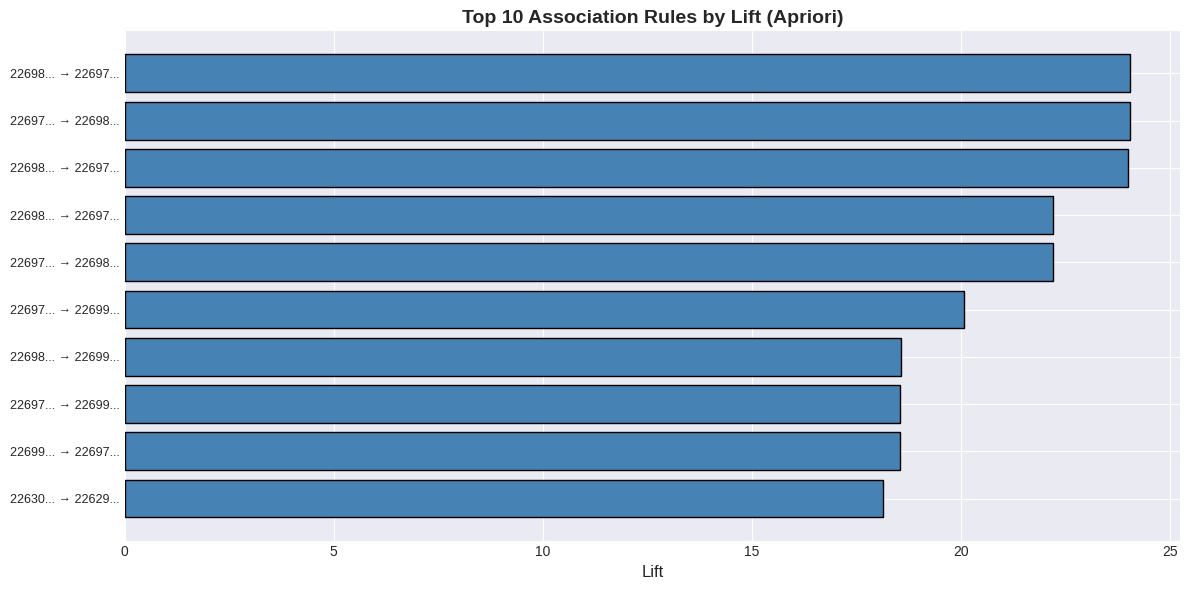


✓ Apriori analysis complete


In [26]:
print(f"{'='*60}")
print("ASSOCIATION RULE MINING - APRIORI")
print(f"{'='*60}")

import time

# Run Apriori
start_time = time.time()
frequent_itemsets_apriori = apriori(basket_filtered, min_support=0.02, use_colnames=True)
apriori_time = time.time() - start_time

print(f"✓ Apriori completed in {apriori_time:.2f} seconds")
print(f"Number of frequent itemsets: {len(frequent_itemsets_apriori)}")

# Generate association rules
rules_apriori = association_rules(frequent_itemsets_apriori, metric="confidence", min_threshold=0.6)

# Filter by lift
rules_apriori_filtered = rules_apriori[rules_apriori['lift'] >= 1.2]

print(f"Number of rules (confidence ≥ 0.6, lift ≥ 1.2): {len(rules_apriori_filtered)}")

# Sort by lift and get top 10
top_rules_apriori = rules_apriori_filtered.sort_values('lift', ascending=False).head(10)

print("\nTop 10 Association Rules by Lift (Apriori):")
print("="*100)
for idx, row in top_rules_apriori.iterrows():
    # Convert frozensets to strings properly
    antecedents = ', '.join([str(item) for item in list(row['antecedents'])])
    consequents = ', '.join([str(item) for item in list(row['consequents'])])
    print(f"\nRule: {antecedents} → {consequents}")
    print(f"  Support: {row['support']:.4f} | Confidence: {row['confidence']:.4f} | Lift: {row['lift']:.4f}")

# Visualize top rules
plt.figure(figsize=(12, 6))
top_rules_plot = top_rules_apriori.head(10).copy()

# Create readable rule names
top_rules_plot['rule'] = top_rules_plot.apply(
    lambda x: f"{str(list(x['antecedents'])[0])[:15]}... → {str(list(x['consequents'])[0])[:15]}...",
    axis=1
)

plt.barh(range(len(top_rules_plot)), top_rules_plot['lift'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_rules_plot)), top_rules_plot['rule'], fontsize=9)
plt.xlabel('Lift', fontsize=12)
plt.title('Top 10 Association Rules by Lift (Apriori)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✓ Apriori analysis complete")

CHUNK 15: FP-Growth Algorithm


ASSOCIATION RULE MINING - FP-GROWTH
✓ FP-Growth completed in 11.46 seconds
Number of frequent itemsets: 251
Number of rules (confidence ≥ 0.6, lift ≥ 1.2): 20

Top 10 Association Rules by Lift (FP-Growth):

Rule: 22698 → 22697, 22699
  Support: 0.0210 | Confidence: 0.7014 | Lift: 24.0278

Rule: 22697, 22699 → 22698
  Support: 0.0210 | Confidence: 0.7209 | Lift: 24.0278

Rule: 22698, 22699 → 22697
  Support: 0.0210 | Confidence: 0.8945 | Lift: 23.9896

Rule: 22698 → 22697
  Support: 0.0248 | Confidence: 0.8273 | Lift: 22.1885

Rule: 22697 → 22698
  Support: 0.0248 | Confidence: 0.6657 | Lift: 22.1885

Rule: 22697, 22698 → 22699
  Support: 0.0210 | Confidence: 0.8478 | Lift: 20.0663

Rule: 22698 → 22699
  Support: 0.0235 | Confidence: 0.7842 | Lift: 18.5598

Rule: 22697 → 22699
  Support: 0.0292 | Confidence: 0.7829 | Lift: 18.5302

Rule: 22699 → 22697
  Support: 0.0292 | Confidence: 0.6909 | Lift: 18.5302

Rule: 22630 → 22629
  Support: 0.0229 | Confidence: 0.6883 | Lift: 18.1190

ALGOR

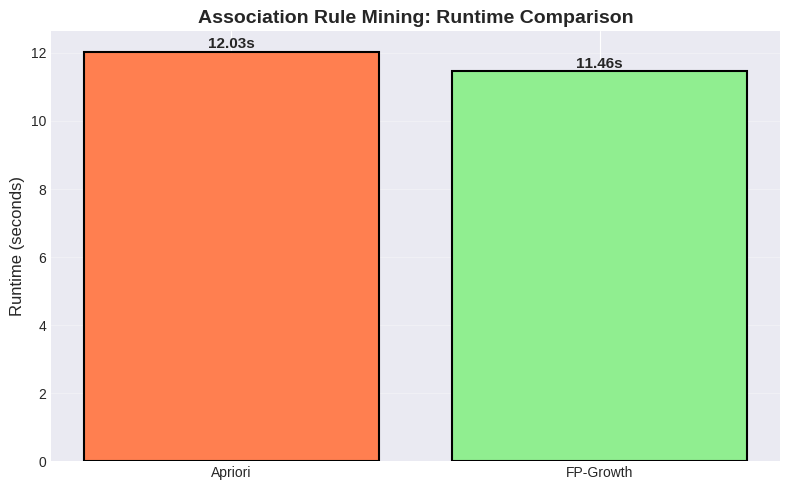


✓ Association rule mining complete


In [27]:
print(f"{'='*60}")
print("ASSOCIATION RULE MINING - FP-GROWTH")
print(f"{'='*60}")

# Run FP-Growth
start_time = time.time()
frequent_itemsets_fpgrowth = fpgrowth(basket_filtered, min_support=0.02, use_colnames=True)
fpgrowth_time = time.time() - start_time

print(f"✓ FP-Growth completed in {fpgrowth_time:.2f} seconds")
print(f"Number of frequent itemsets: {len(frequent_itemsets_fpgrowth)}")

# Generate association rules
rules_fpgrowth = association_rules(frequent_itemsets_fpgrowth, metric="confidence", min_threshold=0.6)

# Filter by lift
rules_fpgrowth_filtered = rules_fpgrowth[rules_fpgrowth['lift'] >= 1.2]

print(f"Number of rules (confidence ≥ 0.6, lift ≥ 1.2): {len(rules_fpgrowth_filtered)}")

# Sort by lift and get top 10
top_rules_fpgrowth = rules_fpgrowth_filtered.sort_values('lift', ascending=False).head(10)

print("\nTop 10 Association Rules by Lift (FP-Growth):")
print("="*100)
for idx, row in top_rules_fpgrowth.iterrows():
    # Convert frozensets to strings properly
    antecedents = ', '.join([str(item) for item in list(row['antecedents'])])
    consequents = ', '.join([str(item) for item in list(row['consequents'])])
    print(f"\nRule: {antecedents} → {consequents}")
    print(f"  Support: {row['support']:.4f} | Confidence: {row['confidence']:.4f} | Lift: {row['lift']:.4f}")

# Runtime comparison
print(f"\n{'='*60}")
print("ALGORITHM RUNTIME COMPARISON")
print(f"{'='*60}")
print(f"Apriori:    {apriori_time:.2f} seconds")
print(f"FP-Growth:  {fpgrowth_time:.2f} seconds")
print(f"Speedup:    {apriori_time/fpgrowth_time:.2f}x" if fpgrowth_time > 0 else "FP-Growth was faster")

# Visualize runtime comparison
plt.figure(figsize=(8, 5))
algorithms = ['Apriori', 'FP-Growth']
times = [apriori_time, fpgrowth_time]
colors = ['coral', 'lightgreen']

plt.bar(algorithms, times, color=colors, edgecolor='black', linewidth=1.5)
plt.ylabel('Runtime (seconds)', fontsize=12)
plt.title('Association Rule Mining: Runtime Comparison', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(times):
    plt.text(i, v + 0.1, f'{v:.2f}s', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Association rule mining complete")

CHUNK 16: Prepare Data for Classification


In [28]:
print(f"{'='*60}")
print("CLASSIFICATION - DATA PREPARATION")
print(f"{'='*60}")

# Create High-Value customer label (Monetary > 75th percentile)
monetary_75th = rfm['Monetary'].quantile(0.75)
rfm['HighValue'] = (rfm['Monetary'] > monetary_75th).astype(int)

print(f"75th percentile of Monetary: ${monetary_75th:.2f}")
print(f"\nClass Distribution:")
print(rfm['HighValue'].value_counts())
print(f"\nClass Balance:")
print(rfm['HighValue'].value_counts(normalize=True))

# Prepare features for Gaussian NB (RFM features)
X_gaussian = rfm[['Recency', 'Frequency', 'Monetary']].values
X_gaussian_scaled = StandardScaler().fit_transform(X_gaussian)
y = rfm['HighValue'].values

# Prepare features for Bernoulli NB (purchase flags)
# Create binary features: did customer buy product category?
# We'll use top 20 most popular products
top_products = df_clean['StockCode'].value_counts().head(20).index

# Create purchase flags
purchase_flags = pd.DataFrame()
for product in top_products:
    purchase_flags[f'Bought_{product}'] = df_clean.groupby('CustomerID')['StockCode'].apply(
        lambda x: 1 if product in x.values else 0
    )

# Merge with RFM
rfm_with_flags = rfm.merge(purchase_flags, left_on='CustomerID', right_index=True, how='left').fillna(0)

X_bernoulli = rfm_with_flags[[col for col in rfm_with_flags.columns if col.startswith('Bought_')]].values

# Train-test split
X_train_gauss, X_test_gauss, y_train, y_test = train_test_split(
    X_gaussian_scaled, y, test_size=0.3, random_state=42, stratify=y
)

X_train_bern, X_test_bern, _, _ = train_test_split(
    X_bernoulli, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\n✓ Data prepared for classification")
print(f"Training set size: {len(y_train)}")
print(f"Test set size: {len(y_test)}")
print(f"Features for Gaussian NB: {X_train_gauss.shape[1]}")
print(f"Features for Bernoulli NB: {X_train_bern.shape[1]}")

CLASSIFICATION - DATA PREPARATION
75th percentile of Monetary: $1661.74

Class Distribution:
HighValue
0    3253
1    1085
Name: count, dtype: int64

Class Balance:
HighValue
0    0.749885
1    0.250115
Name: proportion, dtype: float64

✓ Data prepared for classification
Training set size: 3036
Test set size: 1302
Features for Gaussian NB: 3
Features for Bernoulli NB: 20


CHUNK 17: Gaussian Naïve Bayes


GAUSSIAN NAÏVE BAYES CLASSIFICATION

Gaussian Naïve Bayes Results:
Accuracy:  0.9616
Precision: 0.9726
Recall:    0.8712
F1-Score:  0.9191


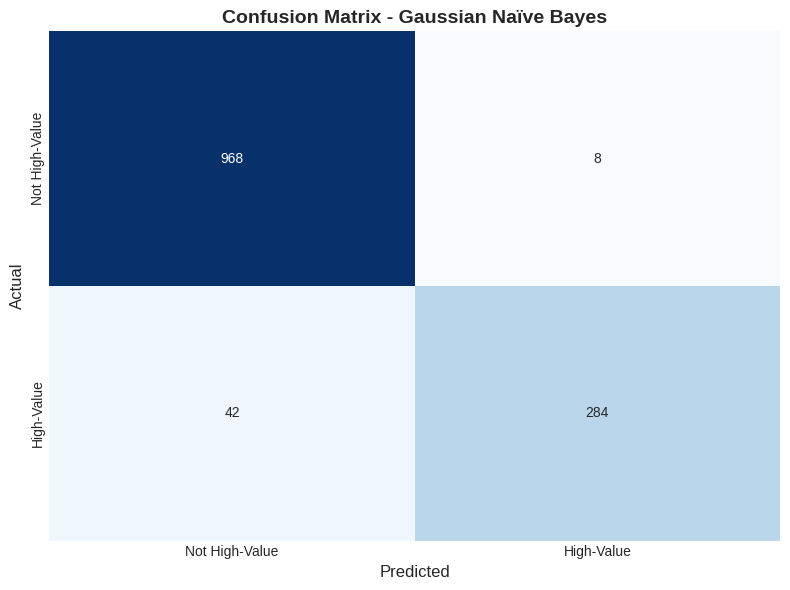

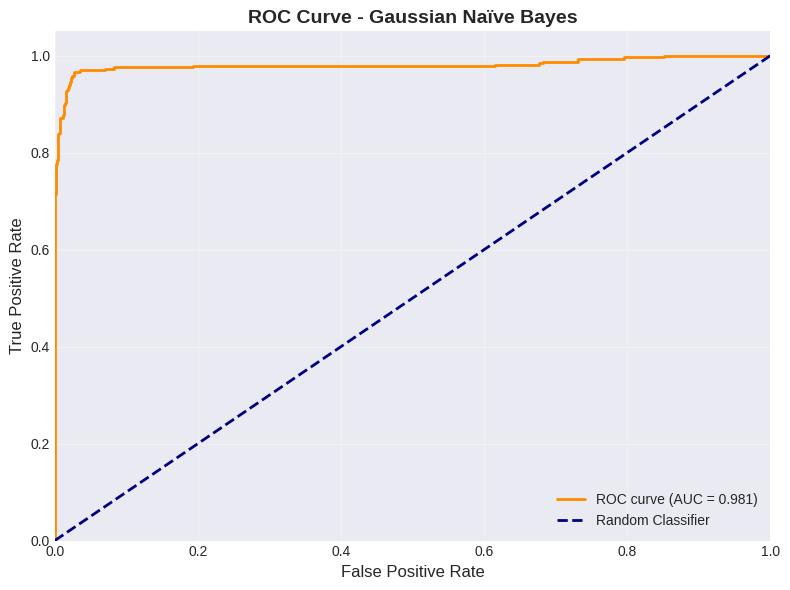


✓ Gaussian NB: AUC = 0.9810


In [29]:
print(f"{'='*60}")
print("GAUSSIAN NAÏVE BAYES CLASSIFICATION")
print(f"{'='*60}")

# Train Gaussian NB
gnb = GaussianNB()
gnb.fit(X_train_gauss, y_train)

# Predictions
y_pred_gnb = gnb.predict(X_test_gauss)
y_pred_proba_gnb = gnb.predict_proba(X_test_gauss)[:, 1]

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb)
recall_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)

print("\nGaussian Naïve Bayes Results:")
print(f"Accuracy:  {accuracy_gnb:.4f}")
print(f"Precision: {precision_gnb:.4f}")
print(f"Recall:    {recall_gnb:.4f}")
print(f"F1-Score:  {f1_gnb:.4f}")

# Confusion Matrix
cm_gnb = confusion_matrix(y_test, y_pred_gnb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not High-Value', 'High-Value'],
            yticklabels=['Not High-Value', 'High-Value'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Gaussian Naïve Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC Curve
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_pred_proba_gnb)
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_gnb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Gaussian Naïve Bayes', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Gaussian NB: AUC = {roc_auc_gnb:.4f}")

CHUNK 18: Bernoulli Naïve Bayes


BERNOULLI NAÏVE BAYES CLASSIFICATION

Bernoulli Naïve Bayes Results:
Accuracy:  0.7926
Precision: 0.5993
Recall:    0.5184
F1-Score:  0.5559


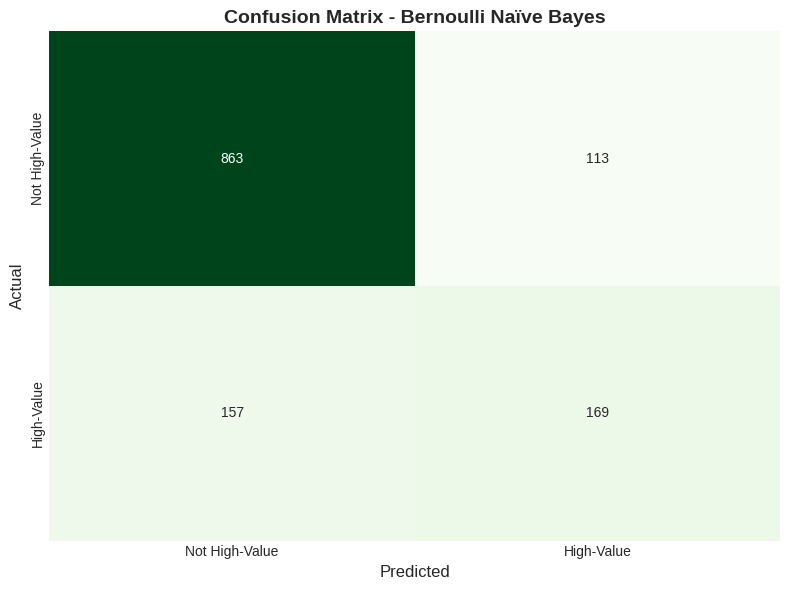

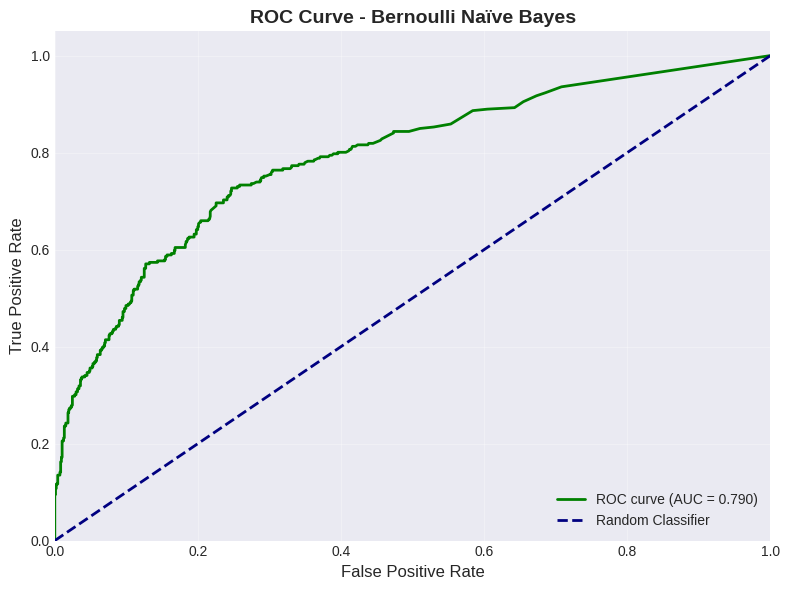


✓ Bernoulli NB: AUC = 0.7901


In [30]:
print(f"{'='*60}")
print("BERNOULLI NAÏVE BAYES CLASSIFICATION")
print(f"{'='*60}")

# Train Bernoulli NB
bnb = BernoulliNB()
bnb.fit(X_train_bern, y_train)

# Predictions
y_pred_bnb = bnb.predict(X_test_bern)
y_pred_proba_bnb = bnb.predict_proba(X_test_bern)[:, 1]

# Evaluation metrics
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)
precision_bnb = precision_score(y_test, y_pred_bnb)
recall_bnb = recall_score(y_test, y_pred_bnb)
f1_bnb = f1_score(y_test, y_pred_bnb)

print("\nBernoulli Naïve Bayes Results:")
print(f"Accuracy:  {accuracy_bnb:.4f}")
print(f"Precision: {precision_bnb:.4f}")
print(f"Recall:    {recall_bnb:.4f}")
print(f"F1-Score:  {f1_bnb:.4f}")

# Confusion Matrix
cm_bnb = confusion_matrix(y_test, y_pred_bnb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not High-Value', 'High-Value'],
            yticklabels=['Not High-Value', 'High-Value'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Bernoulli Naïve Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC Curve
fpr_bnb, tpr_bnb, _ = roc_curve(y_test, y_pred_proba_bnb)
roc_auc_bnb = auc(fpr_bnb, tpr_bnb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bnb, tpr_bnb, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_bnb:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Bernoulli Naïve Bayes', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Bernoulli NB: AUC = {roc_auc_bnb:.4f}")

CHUNK 19: Naïve Bayes Comparison


NAÏVE BAYES MODELS COMPARISON

Model Comparison:
       Model  Accuracy  Precision   Recall  F1-Score      AUC
 Gaussian NB  0.961598   0.972603 0.871166  0.919094 0.980963
Bernoulli NB  0.792627   0.599291 0.518405  0.555921 0.790053


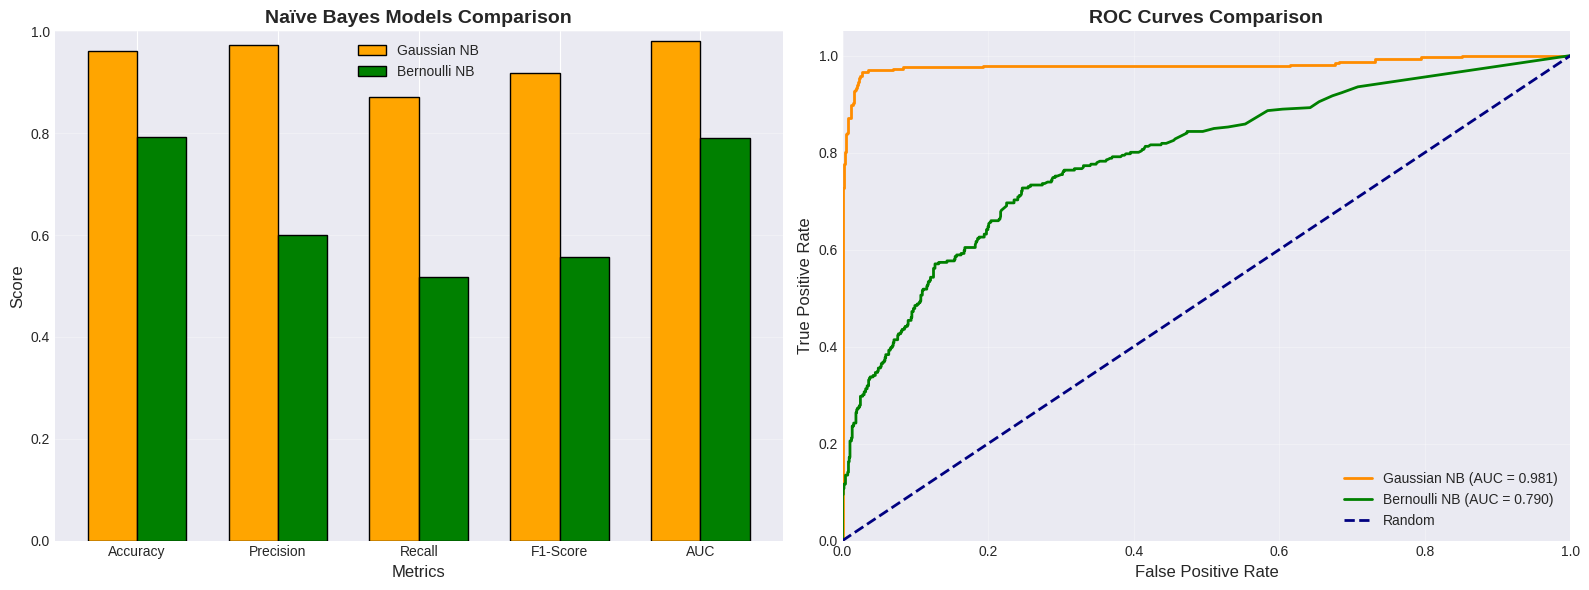


✓ Naïve Bayes analysis complete


In [31]:
print(f"{'='*60}")
print("NAÏVE BAYES MODELS COMPARISON")
print(f"{'='*60}")

# Compare both models
comparison_data = {
    'Model': ['Gaussian NB', 'Bernoulli NB'],
    'Accuracy': [accuracy_gnb, accuracy_bnb],
    'Precision': [precision_gnb, precision_bnb],
    'Recall': [recall_gnb, recall_bnb],
    'F1-Score': [f1_gnb, f1_bnb],
    'AUC': [roc_auc_gnb, roc_auc_bnb]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nModel Comparison:")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
gaussian_scores = [accuracy_gnb, precision_gnb, recall_gnb, f1_gnb, roc_auc_gnb]
bernoulli_scores = [accuracy_bnb, precision_bnb, recall_bnb, f1_bnb, roc_auc_bnb]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, gaussian_scores, width, label='Gaussian NB', color='orange', edgecolor='black')
axes[0].bar(x + width/2, bernoulli_scores, width, label='Bernoulli NB', color='green', edgecolor='black')
axes[0].set_xlabel('Metrics', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Naïve Bayes Models Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# ROC curves comparison
axes[1].plot(fpr_gnb, tpr_gnb, color='darkorange', lw=2, label=f'Gaussian NB (AUC = {roc_auc_gnb:.3f})')
axes[1].plot(fpr_bnb, tpr_bnb, color='green', lw=2, label=f'Bernoulli NB (AUC = {roc_auc_bnb:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Naïve Bayes analysis complete")

CHUNK 20: SVM - Linear Kernel


SUPPORT VECTOR MACHINE - LINEAR KERNEL

Linear SVM Results:
Accuracy:  0.9724
Precision: 0.9932
Recall:    0.8957
F1-Score:  0.9419


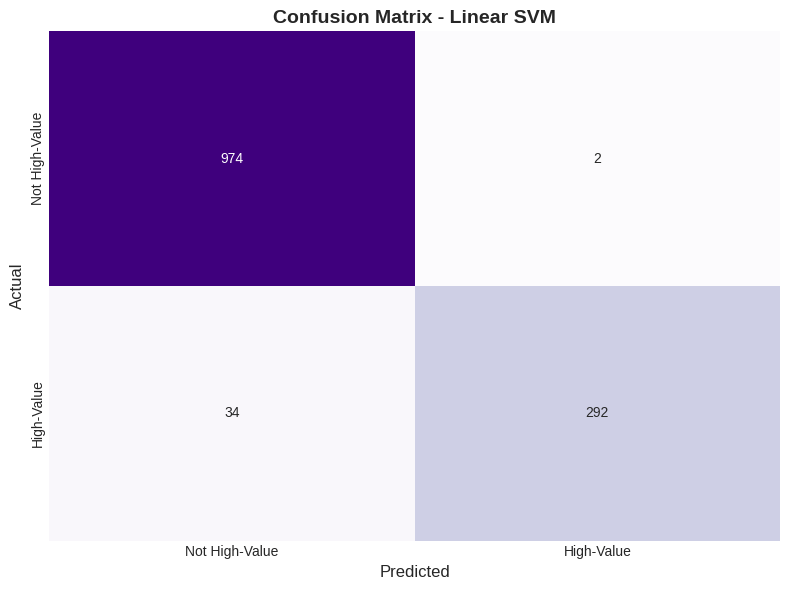

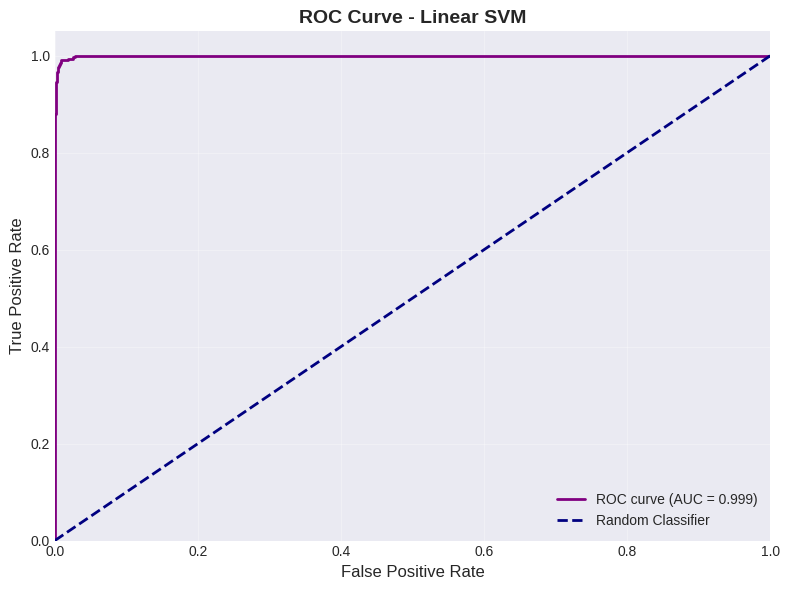


✓ Linear SVM: AUC = 0.9994


In [32]:
print(f"{'='*60}")
print("SUPPORT VECTOR MACHINE - LINEAR KERNEL")
print(f"{'='*60}")

# Train SVM with linear kernel
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_gauss, y_train)

# Predictions
y_pred_svm_linear = svm_linear.predict(X_test_gauss)
y_pred_proba_svm_linear = svm_linear.predict_proba(X_test_gauss)[:, 1]

# Evaluation metrics
accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
precision_svm_linear = precision_score(y_test, y_pred_svm_linear)
recall_svm_linear = recall_score(y_test, y_pred_svm_linear)
f1_svm_linear = f1_score(y_test, y_pred_svm_linear)

print("\nLinear SVM Results:")
print(f"Accuracy:  {accuracy_svm_linear:.4f}")
print(f"Precision: {precision_svm_linear:.4f}")
print(f"Recall:    {recall_svm_linear:.4f}")
print(f"F1-Score:  {f1_svm_linear:.4f}")

# Confusion Matrix
cm_svm_linear = confusion_matrix(y_test, y_pred_svm_linear)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_linear, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Not High-Value', 'High-Value'],
            yticklabels=['Not High-Value', 'High-Value'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Linear SVM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC Curve
fpr_svm_linear, tpr_svm_linear, _ = roc_curve(y_test, y_pred_proba_svm_linear)
roc_auc_svm_linear = auc(fpr_svm_linear, tpr_svm_linear)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm_linear, tpr_svm_linear, color='purple', lw=2,
         label=f'ROC curve (AUC = {roc_auc_svm_linear:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Linear SVM', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ Linear SVM: AUC = {roc_auc_svm_linear:.4f}")

CHUNK 21: SVM - RBF Kernel with Grid Search


SUPPORT VECTOR MACHINE - RBF KERNEL WITH GRID SEARCH
Performing Grid Search...
Parameter grid: {'C': [0.1, 1, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 'scale']}
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✓ Grid Search complete
Best parameters: {'C': 100, 'gamma': 0.1}
Best cross-validation score: 0.9941

RBF SVM Results:
Accuracy:  0.9954
Precision: 0.9969
Recall:    0.9847
F1-Score:  0.9907


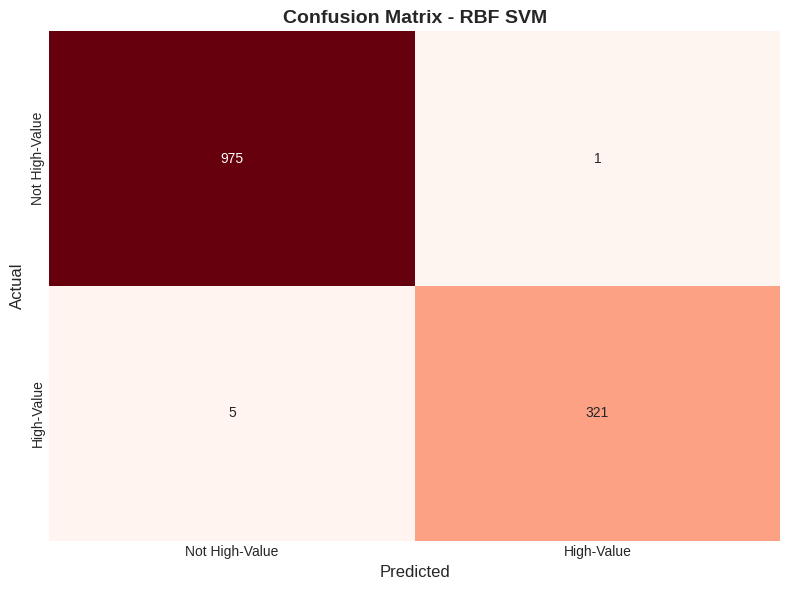

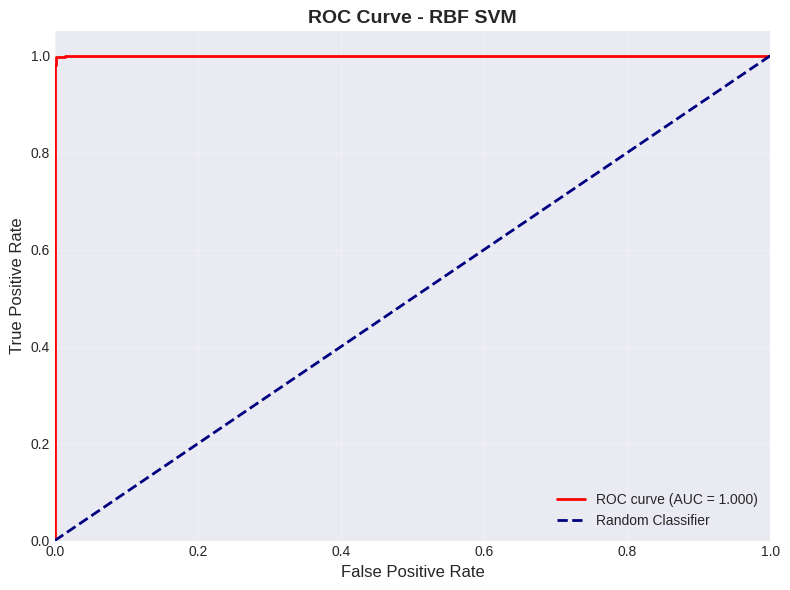


✓ RBF SVM: AUC = 0.9999


In [34]:
print(f"{'='*60}")
print("SUPPORT VECTOR MACHINE - RBF KERNEL WITH GRID SEARCH")
print(f"{'='*60}")

# Grid search for optimal parameters
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale']
}

print("Performing Grid Search...")
print(f"Parameter grid: {param_grid}")

svm_rbf_grid = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=42),
                             param_grid,
                             cv=5,
                             scoring='accuracy',
                             n_jobs=-1,
                             verbose=1)

svm_rbf_grid.fit(X_train_gauss, y_train)

print(f"\n✓ Grid Search complete")
print(f"Best parameters: {svm_rbf_grid.best_params_}")
print(f"Best cross-validation score: {svm_rbf_grid.best_score_:.4f}")

# Get best model
svm_rbf_best = svm_rbf_grid.best_estimator_

# Predictions
y_pred_svm_rbf = svm_rbf_best.predict(X_test_gauss)
y_pred_proba_svm_rbf = svm_rbf_best.predict_proba(X_test_gauss)[:, 1]

# Evaluation metrics
accuracy_svm_rbf = accuracy_score(y_test, y_pred_svm_rbf)
precision_svm_rbf = precision_score(y_test, y_pred_svm_rbf)
recall_svm_rbf = recall_score(y_test, y_pred_svm_rbf)
f1_svm_rbf = f1_score(y_test, y_pred_svm_rbf)

print("\nRBF SVM Results:")
print(f"Accuracy:  {accuracy_svm_rbf:.4f}")
print(f"Precision: {precision_svm_rbf:.4f}")
print(f"Recall:    {recall_svm_rbf:.4f}")
print(f"F1-Score:  {f1_svm_rbf:.4f}")

# Confusion Matrix
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_rbf, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Not High-Value', 'High-Value'],
            yticklabels=['Not High-Value', 'High-Value'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - RBF SVM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC Curve
fpr_svm_rbf, tpr_svm_rbf, _ = roc_curve(y_test, y_pred_proba_svm_rbf)
roc_auc_svm_rbf = auc(fpr_svm_rbf, tpr_svm_rbf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm_rbf, tpr_svm_rbf, color='red', lw=2,
         label=f'ROC curve (AUC = {roc_auc_svm_rbf:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - RBF SVM', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ RBF SVM: AUC = {roc_auc_svm_rbf:.4f}")

CHUNK 22: SVM Decision Boundary Visualization


SVM DECISION BOUNDARY VISUALIZATION


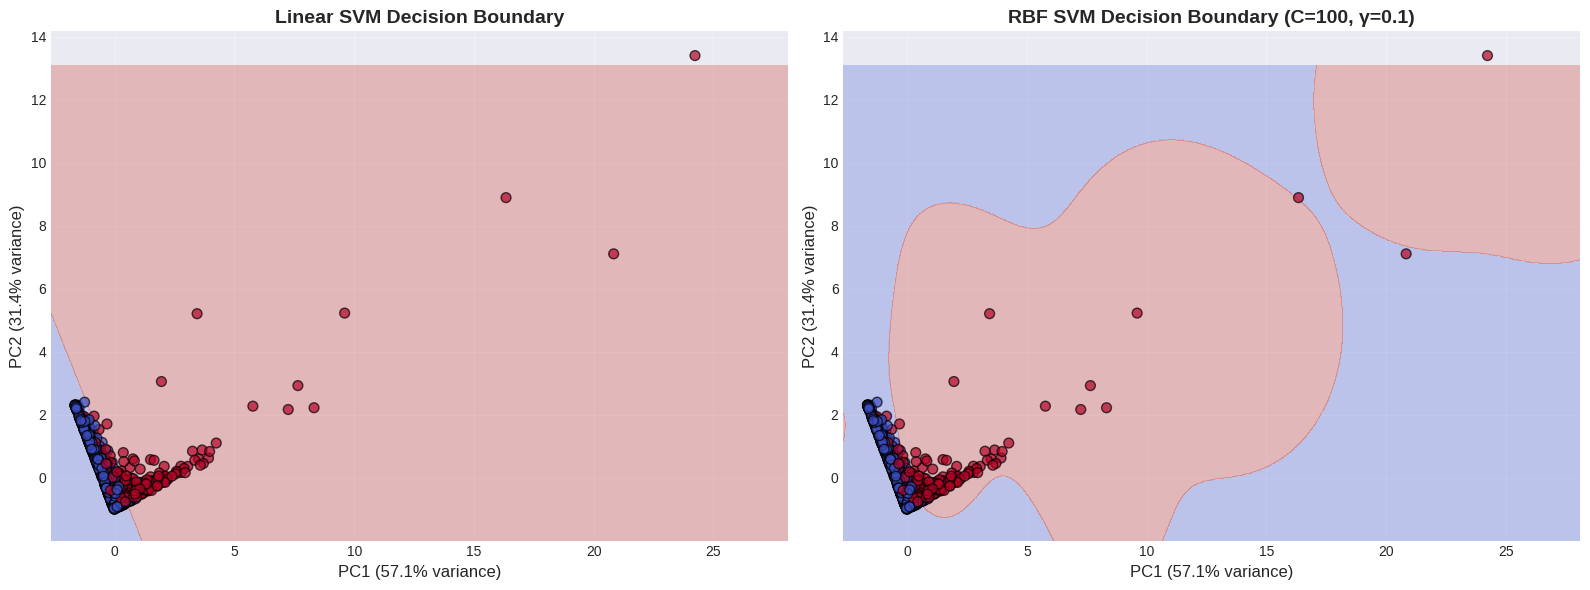

✓ Decision boundary visualization complete


In [35]:
print(f"{'='*60}")
print("SVM DECISION BOUNDARY VISUALIZATION")
print(f"{'='*60}")

# Use PCA to reduce to 2D for visualization
pca_viz = PCA(n_components=2, random_state=42)
X_train_pca = pca_viz.fit_transform(X_train_gauss)
X_test_pca = pca_viz.transform(X_test_gauss)

# Train both SVM models on 2D data
svm_linear_2d = SVC(kernel='linear', random_state=42)
svm_linear_2d.fit(X_train_pca, y_train)

svm_rbf_2d = SVC(kernel='rbf', C=svm_rbf_grid.best_params_['C'],
                 gamma=svm_rbf_grid.best_params_['gamma'], random_state=42)
svm_rbf_2d.fit(X_train_pca, y_train)

# Create mesh for decision boundary
h = 0.02  # step size in the mesh
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Plot decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear SVM
Z_linear = svm_linear_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)

axes[0].contourf(xx, yy, Z_linear, alpha=0.3, cmap='coolwarm')
axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
               cmap='coolwarm', edgecolors='black', s=50, alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[0].set_title('Linear SVM Decision Boundary', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# RBF SVM
Z_rbf = svm_rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

axes[1].contourf(xx, yy, Z_rbf, alpha=0.3, cmap='coolwarm')
axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
               cmap='coolwarm', edgecolors='black', s=50, alpha=0.7)
axes[1].set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
axes[1].set_title(f'RBF SVM Decision Boundary (C={svm_rbf_grid.best_params_["C"]}, γ={svm_rbf_grid.best_params_["gamma"]})',
                 fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Decision boundary visualization complete")

CHUNK 23: SVM Models Comparison


SVM MODELS COMPARISON

SVM Model Comparison:
     Model  Accuracy  Precision   Recall  F1-Score      AUC
Linear SVM  0.972350   0.993197 0.895706  0.941935 0.999428
   RBF SVM  0.995392   0.996894 0.984663  0.990741 0.999934


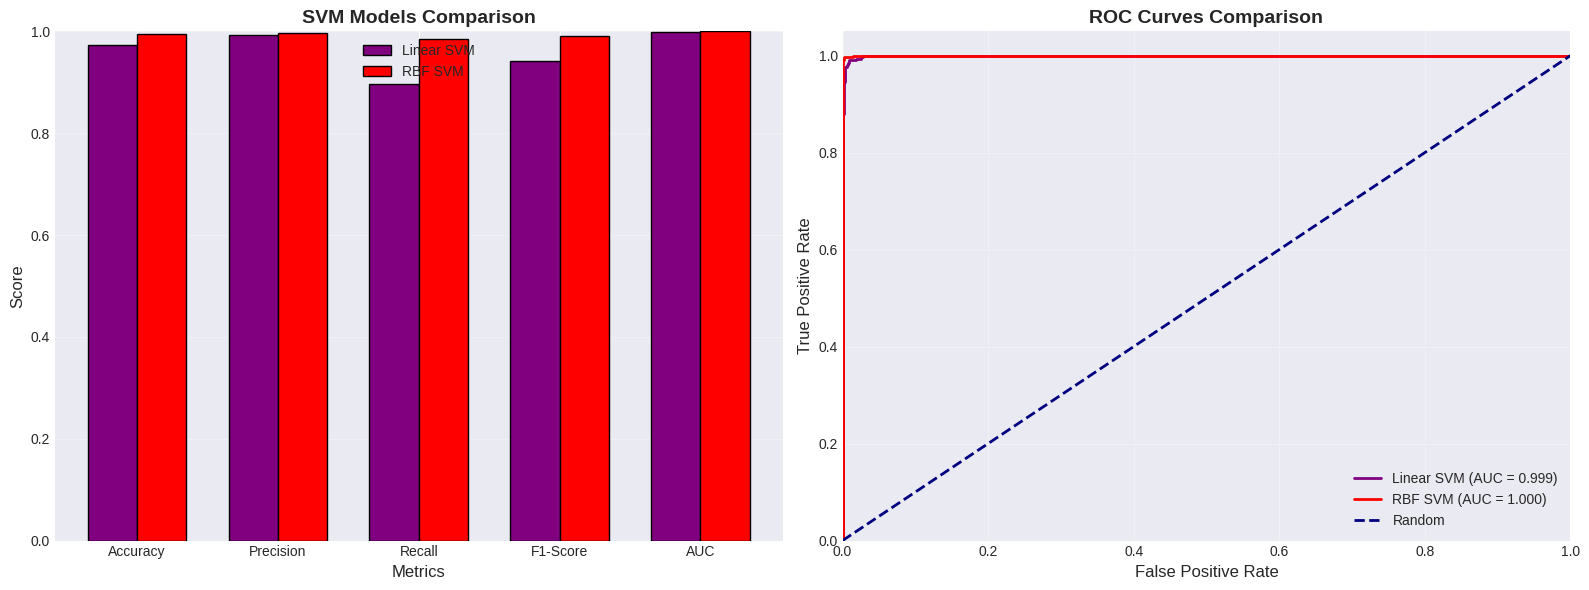


✓ SVM analysis complete


In [36]:
print(f"{'='*60}")
print("SVM MODELS COMPARISON")
print(f"{'='*60}")

# Compare both SVM models
svm_comparison_data = {
    'Model': ['Linear SVM', 'RBF SVM'],
    'Accuracy': [accuracy_svm_linear, accuracy_svm_rbf],
    'Precision': [precision_svm_linear, precision_svm_rbf],
    'Recall': [recall_svm_linear, recall_svm_rbf],
    'F1-Score': [f1_svm_linear, f1_svm_rbf],
    'AUC': [roc_auc_svm_linear, roc_auc_svm_rbf]
}

svm_comparison_df = pd.DataFrame(svm_comparison_data)
print("\nSVM Model Comparison:")
print(svm_comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
linear_scores = [accuracy_svm_linear, precision_svm_linear, recall_svm_linear, f1_svm_linear, roc_auc_svm_linear]
rbf_scores = [accuracy_svm_rbf, precision_svm_rbf, recall_svm_rbf, f1_svm_rbf, roc_auc_svm_rbf]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, linear_scores, width, label='Linear SVM', color='purple', edgecolor='black')
axes[0].bar(x + width/2, rbf_scores, width, label='RBF SVM', color='red', edgecolor='black')
axes[0].set_xlabel('Metrics', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('SVM Models Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# ROC curves comparison
axes[1].plot(fpr_svm_linear, tpr_svm_linear, color='purple', lw=2,
            label=f'Linear SVM (AUC = {roc_auc_svm_linear:.3f})')
axes[1].plot(fpr_svm_rbf, tpr_svm_rbf, color='red', lw=2,
            label=f'RBF SVM (AUC = {roc_auc_svm_rbf:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ SVM analysis complete")

CHUNK 24: All Models Comparison


ALL CLASSIFICATION MODELS COMPARISON

All Classification Models Comparison:
       Model  Accuracy  Precision   Recall  F1-Score      AUC
 Gaussian NB  0.961598   0.972603 0.871166  0.919094 0.980963
Bernoulli NB  0.792627   0.599291 0.518405  0.555921 0.790053
  Linear SVM  0.972350   0.993197 0.895706  0.941935 0.999428
     RBF SVM  0.995392   0.996894 0.984663  0.990741 0.999934

Best Model by Metric:
  Accuracy: RBF SVM (0.9954)
  Precision: RBF SVM (0.9969)
  Recall: RBF SVM (0.9847)
  F1-Score: RBF SVM (0.9907)
  AUC: RBF SVM (0.9999)


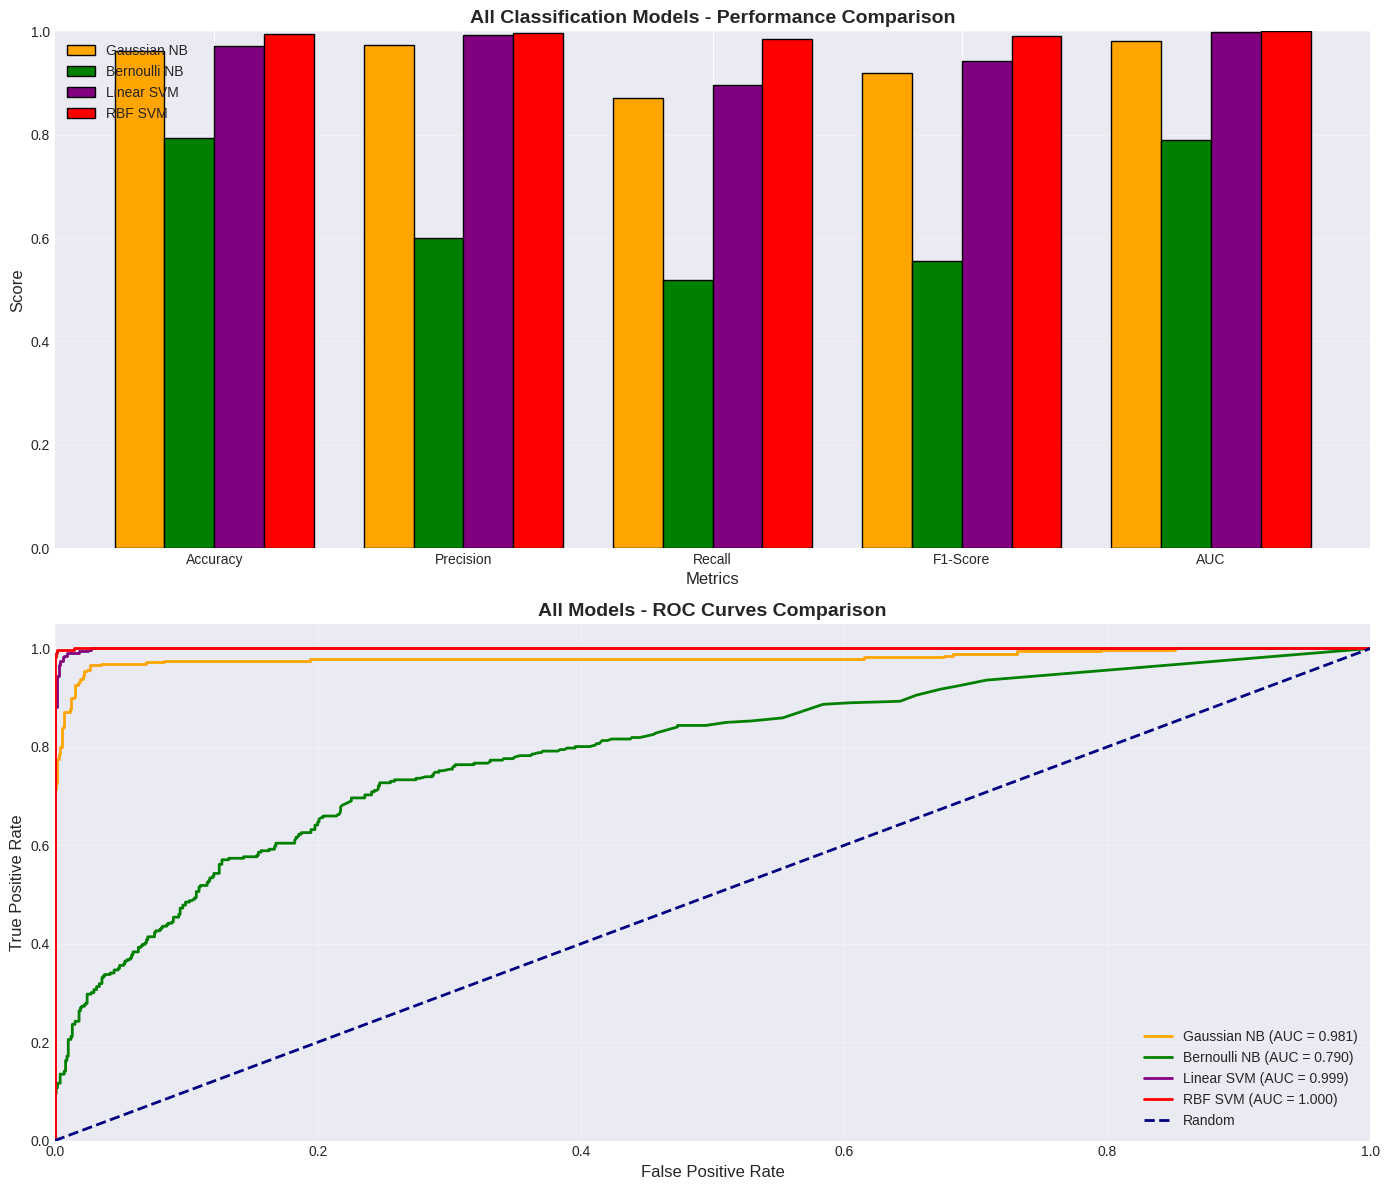


✓ Complete classification analysis finished


In [37]:
print(f"{'='*60}")
print("ALL CLASSIFICATION MODELS COMPARISON")
print(f"{'='*60}")

# Comprehensive comparison
all_models_data = {
    'Model': ['Gaussian NB', 'Bernoulli NB', 'Linear SVM', 'RBF SVM'],
    'Accuracy': [accuracy_gnb, accuracy_bnb, accuracy_svm_linear, accuracy_svm_rbf],
    'Precision': [precision_gnb, precision_bnb, precision_svm_linear, precision_svm_rbf],
    'Recall': [recall_gnb, recall_bnb, recall_svm_linear, recall_svm_rbf],
    'F1-Score': [f1_gnb, f1_bnb, f1_svm_linear, f1_svm_rbf],
    'AUC': [roc_auc_gnb, roc_auc_bnb, roc_auc_svm_linear, roc_auc_svm_rbf]
}

all_models_df = pd.DataFrame(all_models_data)
print("\nAll Classification Models Comparison:")
print(all_models_df.to_string(index=False))

# Find best model for each metric
print("\nBest Model by Metric:")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']:
    best_idx = all_models_df[metric].idxmax()
    best_model = all_models_df.loc[best_idx, 'Model']
    best_score = all_models_df.loc[best_idx, metric]
    print(f"  {metric}: {best_model} ({best_score:.4f})")

# Visualize comprehensive comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(metrics))
width = 0.2

colors = ['orange', 'green', 'purple', 'red']
for i, model in enumerate(all_models_df['Model']):
    scores = all_models_df.iloc[i][['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']].values
    axes[0].bar(x + i*width, scores, width, label=model, color=colors[i], edgecolor='black')

axes[0].set_xlabel('Metrics', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('All Classification Models - Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# ROC curves comparison
axes[1].plot(fpr_gnb, tpr_gnb, color='orange', lw=2, label=f'Gaussian NB (AUC = {roc_auc_gnb:.3f})')
axes[1].plot(fpr_bnb, tpr_bnb, color='green', lw=2, label=f'Bernoulli NB (AUC = {roc_auc_bnb:.3f})')
axes[1].plot(fpr_svm_linear, tpr_svm_linear, color='purple', lw=2, label=f'Linear SVM (AUC = {roc_auc_svm_linear:.3f})')
axes[1].plot(fpr_svm_rbf, tpr_svm_rbf, color='red', lw=2, label=f'RBF SVM (AUC = {roc_auc_svm_rbf:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('All Models - ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Complete classification analysis finished")